# 1. Thư viện và dữ liệu

In [1]:
import pandas as pd
from src.processing.aggregate import prepare_level_data
from src.model.prophet import ProphetModel
from src.model.arima import ARIMAModel


D:\Mortality_Rate_Forecasting_true\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = "../data/time_series_country.csv"
df = pd.read_csv(file_path, sep=",", engine="python")


# 2.Dự báo tỷ lệ tử vong

## 2.1. Global model

In [3]:
global_df = prepare_level_data(df, level="global")
global_model = ARIMAModel(global_df)

In [4]:
forecast_df =global_model.arima_forecast(0, 1, 0, steps=6)
print(forecast_df)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25              1.097062  1.871337      -2.570691       4.764815
26              1.097062  2.646470      -4.089924       6.284048
27              1.097062  3.241251      -5.255672       7.449796
28              1.097062  3.742674      -6.238444       8.432568
29              1.097062  4.184437      -7.104283       9.298407
30              1.097062  4.583821      -7.887061      10.081185


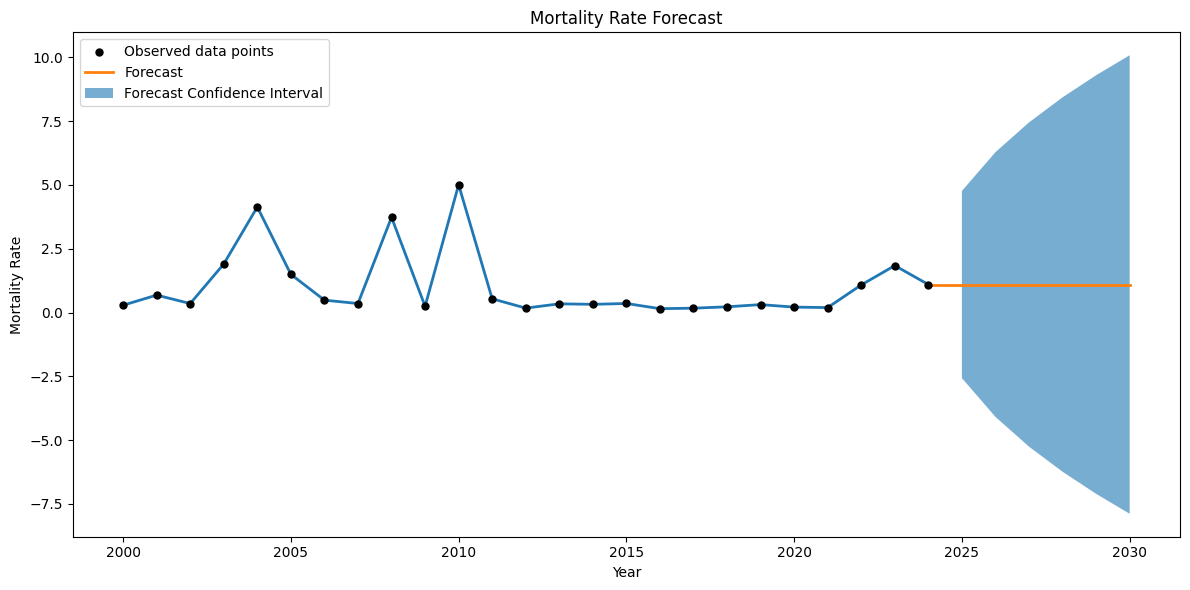

In [5]:
global_model.plot_forecast(0, 1, 0, steps=6)

In [6]:
# Hậu xử lý & Benchmarks dùng hàm arima_...
cleaned_arima = global_model.arima_post_process(forecast_df)
print("============Benchmark 1 (Trung bình)===================")
# 2. Chạy Benchmark 1 (Trung bình)
global_model.arima_mean_strategy(cleaned_arima)

print("============Benchmark 2 (Tốc độ thay đổi)===================")
global_model.arima_yoy_strategy(cleaned_arima)


 Mortality Rate Forecast (2025-2030) - ARIMA Cắt Âm 
Mortality_Rate      mean  mean_ci_lower  mean_ci_upper
25              1.097062            0.0       4.764815
26              1.097062            0.0       6.284048
27              1.097062            0.0       7.449796
28              1.097062            0.0       8.432568
29              1.097062            0.0       9.298407
30              1.097062            0.0      10.081185
Mean mean_ci_lower (last 6): 0.000000
Mean mean_ci_upper (last 6): 7.718470
============Benchmark 1 (Trung bình)===================
Historical Mean Mortality Rate: 1.0272
Forecast Mean Mortality Rate (2025-2030): 1.0971
25% Reduction Threshold (Target <= 0.7704)
50% Reduction Threshold (Target <= 0.5136)
No: 25% reduction
No: 50% reduction
============Benchmark 2 (Tốc độ thay đổi)===================
Historical Average YoY Change (Benchmark): 0.033806

Forecasted YoY Changes (ARIMA):
        mean  year_on_year_change
25  1.097062                  0.0
26  1

## 2.2. Region Level

### 2.2.1. South Asia

In [7]:
south_asia = prepare_level_data(df,level='region', filter='South Asia')
south_asia_model = ARIMAModel(south_asia)
south_asia_forecast = south_asia_model.arima_forecast(0, 1, 1, steps=6)
print(south_asia_forecast)


Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25              0.244388  1.120733      -1.952209       2.440984
26              0.244388  1.288144      -2.280329       2.769104
27              0.244388  1.436172      -2.570457       3.059232
28              0.244388  1.570306      -2.833356       3.322132
29              0.244388  1.693852      -3.075502       3.564277
30              0.244388  1.808980      -3.301148       3.789923


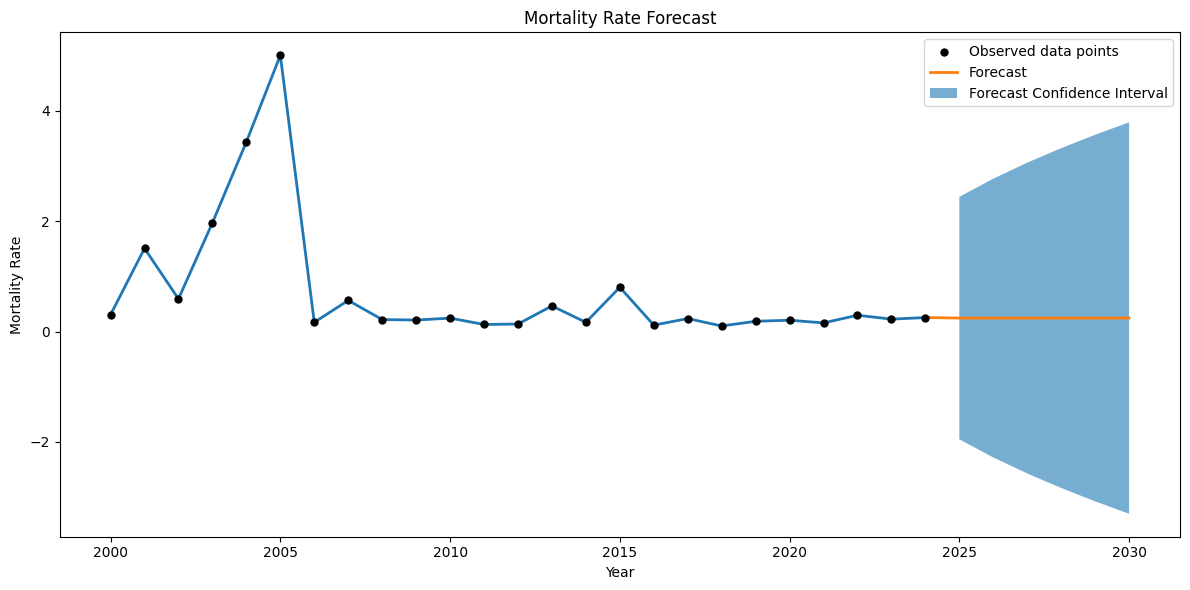

In [8]:
south_asia_model.plot_forecast(0, 1, 1, steps=6)

In [9]:
# Hậu xử lý & Benchmarks dùng hàm arima_...
cleaned_arima = south_asia_model.arima_post_process(south_asia_forecast)
print("============Benchmark 1 (Trung bình)===================")
# 2. Chạy Benchmark 1 (Trung bình)
south_asia_model.arima_mean_strategy(cleaned_arima)

print("============Benchmark 2 (Tốc độ thay đổi)===================")
south_asia_model.arima_yoy_strategy(cleaned_arima)


 Mortality Rate Forecast (2025-2030) - ARIMA Cắt Âm 
Mortality_Rate      mean  mean_ci_lower  mean_ci_upper
25              0.244388            0.0       2.440984
26              0.244388            0.0       2.769104
27              0.244388            0.0       3.059232
28              0.244388            0.0       3.322132
29              0.244388            0.0       3.564277
30              0.244388            0.0       3.789923
Mean mean_ci_lower (last 6): 0.000000
Mean mean_ci_upper (last 6): 3.157609
============Benchmark 1 (Trung bình)===================
Historical Mean Mortality Rate: 0.7074
Forecast Mean Mortality Rate (2025-2030): 0.2444
25% Reduction Threshold (Target <= 0.5306)
50% Reduction Threshold (Target <= 0.3537)
Yes: 25% reduction
Yes: 50% reduction
============Benchmark 2 (Tốc độ thay đổi)===================
Historical Average YoY Change (Benchmark): -0.002185

Forecasted YoY Changes (ARIMA):
        mean  year_on_year_change
25  0.244388            -0.009062
26

### 2.2.2. Europe and Central Asia

In [3]:
europe_central_asia= prepare_level_data(df,level='region', filter='Europe and Central Asia')
europe_central_asia_model = ProphetModel(europe_central_asia)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2003, 2010, 2022, 2023, 2024]
europe_central_asia_forecast = europe_central_asia_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(europe_central_asia_forecast)

23:46:01 - cmdstanpy - INFO - Chain [1] start processing
23:46:01 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31 -0.192328   -1.138476    0.765492
26 2026-12-31 -0.222577   -1.193107    0.684080
27 2027-12-31 -0.252825   -1.191215    0.670334
28 2028-12-31 -0.283157   -1.263199    0.715805
29 2029-12-31 -0.313405   -1.285892    0.623190
30 2030-12-31 -0.343654   -1.273976    0.603428


23:46:05 - cmdstanpy - INFO - Chain [1] start processing
23:46:05 - cmdstanpy - INFO - Chain [1] done processing


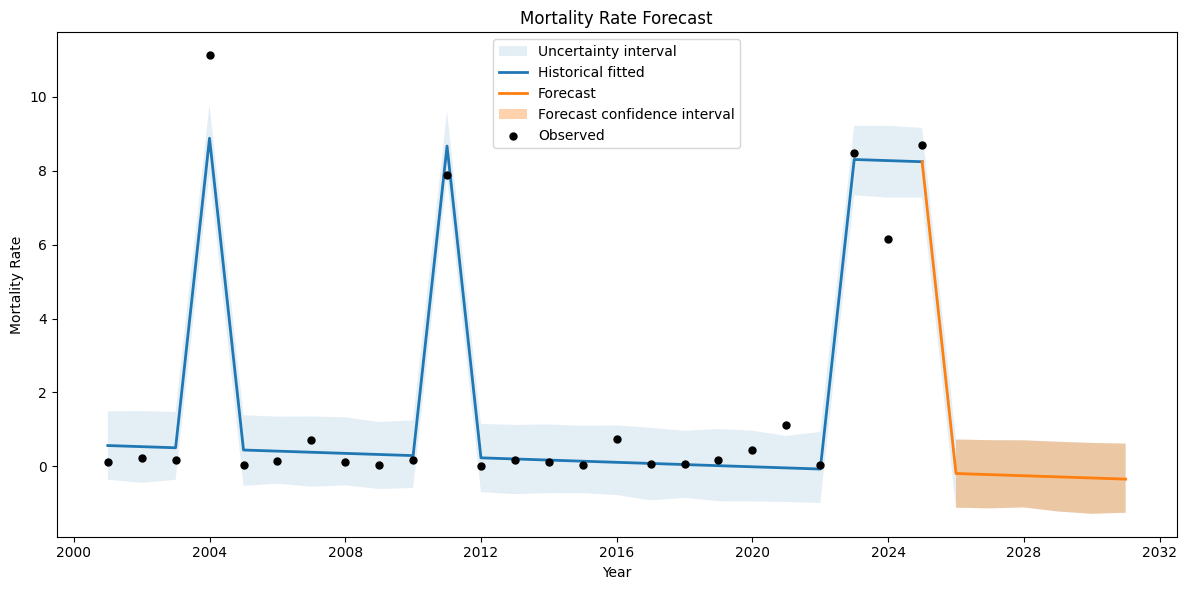

In [4]:
europe_central_asia_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

In [5]:
# 1. Xử lý âm yhat_lower và in bảng
cleaned_df = europe_central_asia_model.process_and_print_forecast(europe_central_asia_forecast)
print("============Benchmark 1 (Trung bình)===================")
# 2. Chạy Benchmark 1 (Trung bình)
europe_central_asia_model.evaluate_benchmark_mean(cleaned_df)
print("============Benchmark 2 (Tốc độ thay đổi)===================")
# 3. Chạy Benchmark 2 (Tốc độ thay đổi)
europe_central_asia_model.evaluate_benchmark_yoy(cleaned_df)


 Mortality Rate Forecast (2025-2030) - cắt âm 
           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31 -0.192328         0.0    0.765492
26 2026-12-31 -0.222577         0.0    0.684080
27 2027-12-31 -0.252825         0.0    0.670334
28 2028-12-31 -0.283157         0.0    0.715805
29 2029-12-31 -0.313405         0.0    0.623190
30 2030-12-31 -0.343654         0.0    0.603428
Mean yhat_lower (last 7): 0.000000
Mean yhat_upper (last 7): 0.677055
============Benchmark 1 (Trung bình)===================
Historical Mean Mortality Rate: 1.8854
Forecast Mean Mortality Rate (2025-2030): -0.2680
25% Reduction Threshold (Target <= 1.4141)
50% Reduction Threshold (Target <= 0.9427)
Yes: 25% reduction
Yes: 50% reduction
============Benchmark 2 (Tốc độ thay đổi)===================
Historical Average YoY Change (Benchmark): 0.357437

Forecasted YoY Changes:
           ds      yhat  year_on_year_change
25 2025-12-31 -0.192328                  NaN
26 2026-12-31 -0.222577            -0.030248
27 2

### 2.2.3. Middle East and North Africa

In [10]:
middle_east_north_africa = prepare_level_data(df,level='region', filter='Middle East and North Africa')
middle_east_north_africa_model = ARIMAModel(middle_east_north_africa)
middle_east_north_africa_forecast = middle_east_north_africa_model.arima_forecast(1, 0, 1, steps=6)
print(middle_east_north_africa_forecast)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25             -0.250857  4.610982      -9.288216       8.786502
26             -0.067952  4.639914      -9.162017       9.026113
27              0.089246  4.661170      -9.046479       9.224972
28              0.224350  4.676809      -8.942027       9.390726
29              0.340465  4.688327      -8.848487       9.529416
30              0.440260  4.696816      -8.765331       9.645851


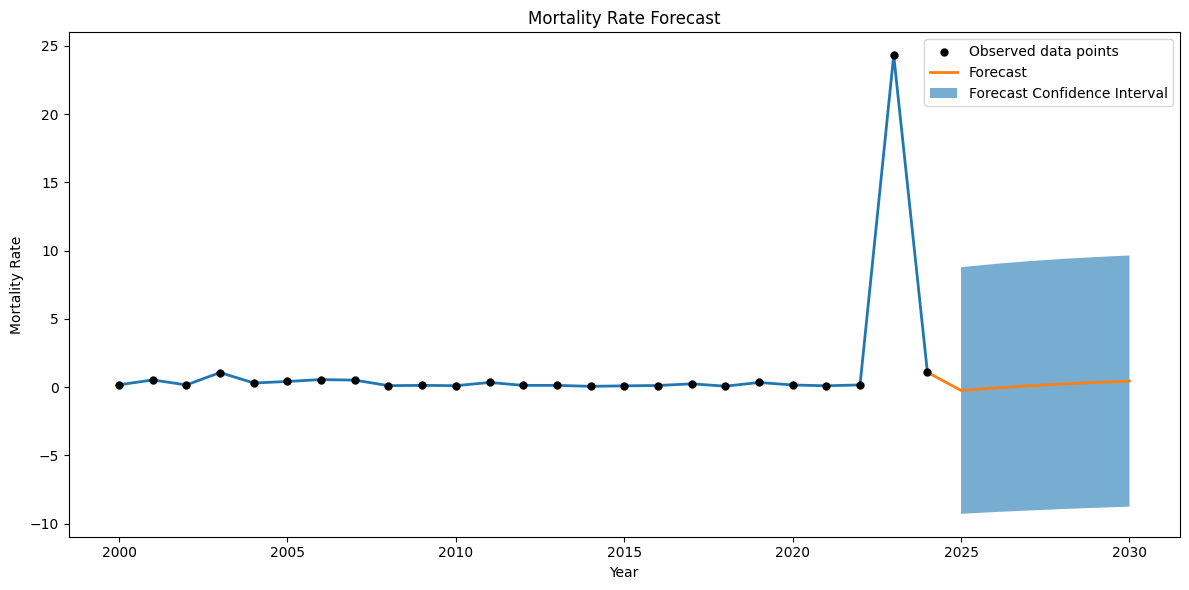

In [11]:
middle_east_north_africa_model.plot_forecast(1, 0, 1, steps=6)

In [12]:
# Hậu xử lý & Benchmarks dùng hàm arima_...
cleaned_arima = middle_east_north_africa_model.arima_post_process(middle_east_north_africa_forecast)
print("============Benchmark 1 (Trung bình)===================")
# 2. Chạy Benchmark 1 (Trung bình)
middle_east_north_africa_model.arima_mean_strategy(cleaned_arima)

print("============Benchmark 2 (Tốc độ thay đổi)===================")
middle_east_north_africa_model.arima_yoy_strategy(cleaned_arima)


 Mortality Rate Forecast (2025-2030) - ARIMA Cắt Âm 
Mortality_Rate      mean  mean_ci_lower  mean_ci_upper
25             -0.250857            0.0       8.786502
26             -0.067952            0.0       9.026113
27              0.089246            0.0       9.224972
28              0.224350            0.0       9.390726
29              0.340465            0.0       9.529416
30              0.440260            0.0       9.645851
Mean mean_ci_lower (last 6): 0.000000
Mean mean_ci_upper (last 6): 9.267263
============Benchmark 1 (Trung bình)===================
Historical Mean Mortality Rate: 1.2518
Forecast Mean Mortality Rate (2025-2030): 0.1293
25% Reduction Threshold (Target <= 0.9389)
50% Reduction Threshold (Target <= 0.6259)
Yes: 25% reduction
Yes: 50% reduction
============Benchmark 2 (Tốc độ thay đổi)===================
Historical Average YoY Change (Benchmark): 0.038327

Forecasted YoY Changes (ARIMA):
        mean  year_on_year_change
25 -0.250857            -1.334812
26 

### 2.2.4. East Asia and Pacific

In [6]:
east_asia_pacific = prepare_level_data(df,level='region', filter='East Asia and Pacific')
east_asia_pacific_model = ProphetModel(east_asia_pacific)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(10.0)
}
holiday_years = [2004, 2008, 2011]
east_asia_pacific_forecast = east_asia_pacific_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(east_asia_pacific_forecast)

23:46:25 - cmdstanpy - INFO - Chain [1] start processing
23:46:25 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31 -0.122718   -1.942924    1.630916
26 2026-12-31 -0.148197   -1.882178    1.702508
27 2027-12-31 -0.173676   -1.956134    1.770602
28 2028-12-31 -0.199225   -2.076016    1.674397
29 2029-12-31 -0.224704   -2.006213    1.752575
30 2030-12-31 -0.250183   -2.082561    1.534672


23:46:28 - cmdstanpy - INFO - Chain [1] start processing
23:46:29 - cmdstanpy - INFO - Chain [1] done processing


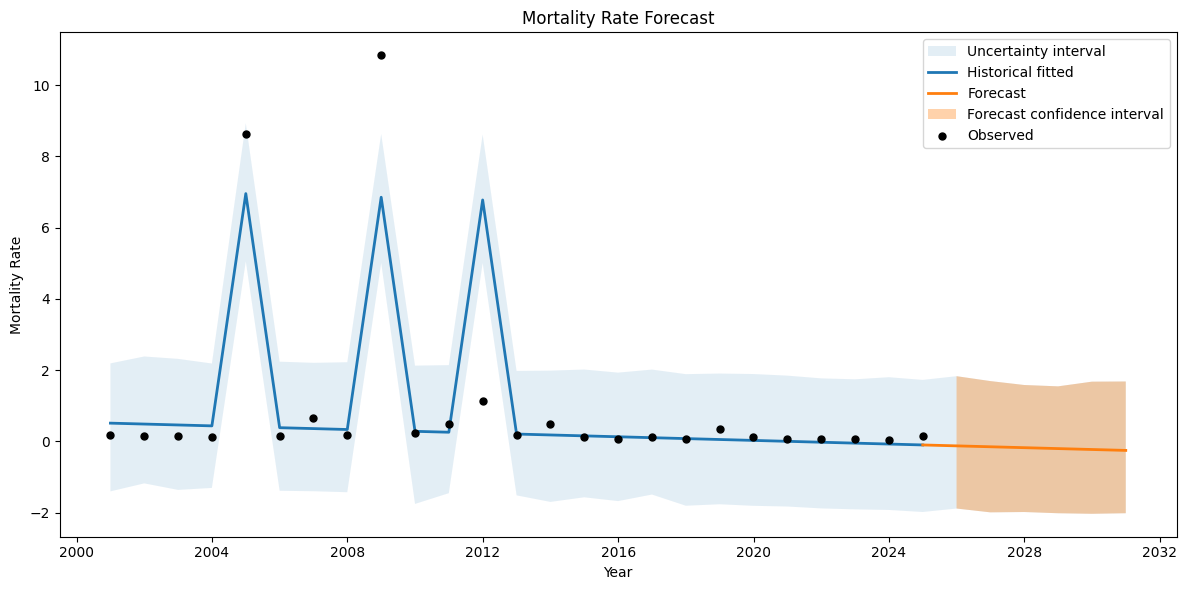

In [7]:
east_asia_pacific_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

In [8]:
# 1. Xử lý âm yhat_lower và in bảng
cleaned_df = east_asia_pacific_model.process_and_print_forecast(east_asia_pacific_forecast)

# 2. Chạy Benchmark 1 (Trung bình)
east_asia_pacific_model.evaluate_benchmark_mean(cleaned_df)

# 3. Chạy Benchmark 2 (Tốc độ thay đổi)
east_asia_pacific_model.evaluate_benchmark_yoy(cleaned_df)


 Mortality Rate Forecast (2025-2030) - cắt âm 
           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31 -0.122718         0.0    1.630916
26 2026-12-31 -0.148197         0.0    1.702508
27 2027-12-31 -0.173676         0.0    1.770602
28 2028-12-31 -0.199225         0.0    1.674397
29 2029-12-31 -0.224704         0.0    1.752575
30 2030-12-31 -0.250183         0.0    1.534672
Mean yhat_lower (last 7): 0.000000
Mean yhat_upper (last 7): 1.677611
Historical Mean Mortality Rate: 0.9932
Forecast Mean Mortality Rate (2025-2030): -0.1865
25% Reduction Threshold (Target <= 0.7449)
50% Reduction Threshold (Target <= 0.4966)
Yes: 25% reduction
Yes: 50% reduction
Historical Average YoY Change (Benchmark): -0.000364

Forecasted YoY Changes:
           ds      yhat  year_on_year_change
25 2025-12-31 -0.122718                  NaN
26 2026-12-31 -0.148197            -0.025479
27 2027-12-31 -0.173676            -0.025479
28 2028-12-31 -0.199225            -0.025549
29 2029-12-31 -0.224704       

### 2.2.5. Sub-Saharan Africa

In [9]:
subsaharan_africa = prepare_level_data(df,level='region', filter='Sub-Saharan Africa')
subsaharan_africa_model = ProphetModel(subsaharan_africa)
best_params = {
    "changepoint_prior_scale": float(0.2),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2010, 2014]
subsaharan_africa_forecast = subsaharan_africa_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(subsaharan_africa_forecast)

23:46:38 - cmdstanpy - INFO - Chain [1] start processing
23:46:38 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.610528    0.263219    0.965769
26 2026-12-31  0.636273    0.267927    0.997856
27 2027-12-31  0.662018    0.272895    1.029534
28 2028-12-31  0.687834    0.312025    1.021804
29 2029-12-31  0.713579    0.415233    1.068116
30 2030-12-31  0.739324    0.357793    1.112955


23:46:41 - cmdstanpy - INFO - Chain [1] start processing
23:46:41 - cmdstanpy - INFO - Chain [1] done processing


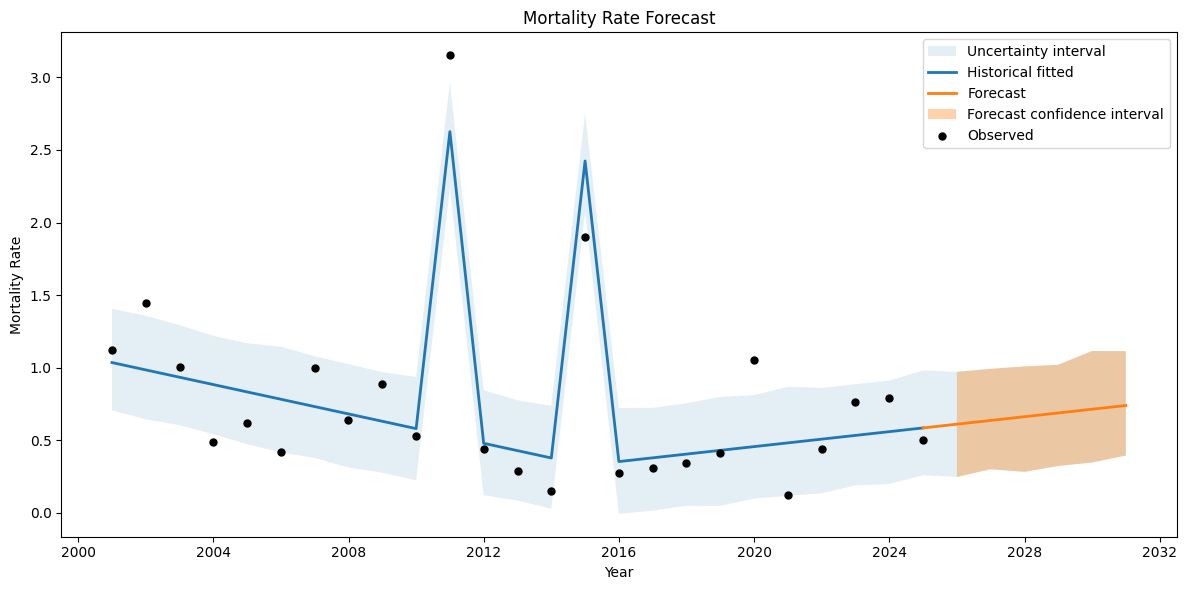

In [10]:
subsaharan_africa_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

In [11]:
# 1. Xử lý âm yhat_lower và in bảng
cleaned_df = subsaharan_africa_model.process_and_print_forecast(subsaharan_africa_forecast)

# 2. Chạy Benchmark 1 (Trung bình)
subsaharan_africa_model.evaluate_benchmark_mean(cleaned_df)

# 3. Chạy Benchmark 2 (Tốc độ thay đổi)
subsaharan_africa_model.evaluate_benchmark_yoy(cleaned_df)


 Mortality Rate Forecast (2025-2030) - cắt âm 
           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.610528    0.263219    0.965769
26 2026-12-31  0.636273    0.267927    0.997856
27 2027-12-31  0.662018    0.272895    1.029534
28 2028-12-31  0.687834    0.312025    1.021804
29 2029-12-31  0.713579    0.415233    1.068116
30 2030-12-31  0.739324    0.357793    1.112955
Mean yhat_lower (last 7): 0.314849
Mean yhat_upper (last 7): 1.032672
Historical Mean Mortality Rate: 0.7640
Forecast Mean Mortality Rate (2025-2030): 0.6749
25% Reduction Threshold (Target <= 0.5730)
50% Reduction Threshold (Target <= 0.3820)
No: 25% reduction
No: 50% reduction
Historical Average YoY Change (Benchmark): -0.025940

Forecasted YoY Changes:
           ds      yhat  year_on_year_change
25 2025-12-31  0.610528                  NaN
26 2026-12-31  0.636273             0.025745
27 2027-12-31  0.662018             0.025745
28 2028-12-31  0.687834             0.025816
29 2029-12-31  0.713579          

### 2.2.6. Latin America and Caribbean

In [13]:
latin_america_caribbean = prepare_level_data(df,level='region', filter='Latin America and Caribbean')
latin_america_caribbean_model = ProphetModel(latin_america_caribbean)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2010]
latin_america_caribbean_forecast = latin_america_caribbean_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(latin_america_caribbean_forecast)

23:47:45 - cmdstanpy - INFO - Chain [1] start processing
23:47:45 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.220883   -0.020033    0.455374
26 2026-12-31  0.222211   -0.021457    0.469025
27 2027-12-31  0.223538   -0.025895    0.453028
28 2028-12-31  0.224870   -0.028229    0.497149
29 2029-12-31  0.226197   -0.028430    0.490809
30 2030-12-31  0.227525   -0.063526    0.503612


23:47:48 - cmdstanpy - INFO - Chain [1] start processing
23:47:48 - cmdstanpy - INFO - Chain [1] done processing


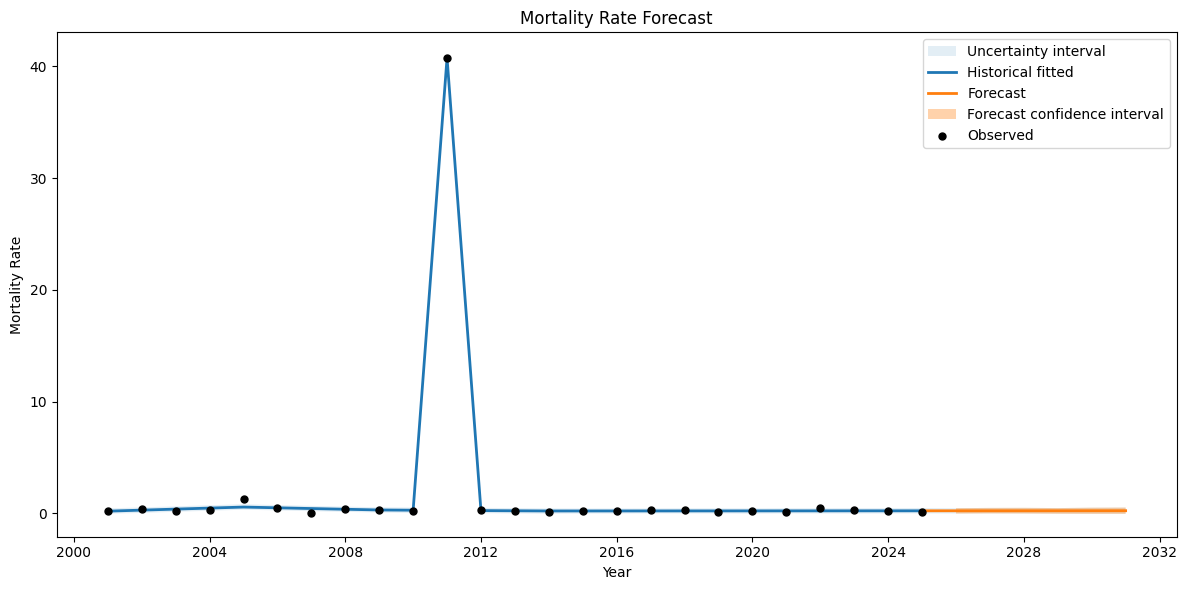

In [14]:
latin_america_caribbean_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

In [15]:
# 1. Xử lý âm yhat_lower và in bảng
cleaned_df = latin_america_caribbean_model.process_and_print_forecast(latin_america_caribbean_forecast)

# 2. Chạy Benchmark 1 (Trung bình)
latin_america_caribbean_model.evaluate_benchmark_mean(cleaned_df)

# 3. Chạy Benchmark 2 (Tốc độ thay đổi)
latin_america_caribbean_model.evaluate_benchmark_yoy(cleaned_df)


 Mortality Rate Forecast (2025-2030) - cắt âm 
           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.220883         0.0    0.455374
26 2026-12-31  0.222211         0.0    0.469025
27 2027-12-31  0.223538         0.0    0.453028
28 2028-12-31  0.224870         0.0    0.497149
29 2029-12-31  0.226197         0.0    0.490809
30 2030-12-31  0.227525         0.0    0.503612
Mean yhat_lower (last 7): 0.000000
Mean yhat_upper (last 7): 0.478166
Historical Mean Mortality Rate: 1.8982
Forecast Mean Mortality Rate (2025-2030): 0.2242
25% Reduction Threshold (Target <= 1.4236)
50% Reduction Threshold (Target <= 0.9491)
Yes: 25% reduction
Yes: 50% reduction
Historical Average YoY Change (Benchmark): -0.000974

Forecasted YoY Changes:
           ds      yhat  year_on_year_change
25 2025-12-31  0.220883                  NaN
26 2026-12-31  0.222211             0.001328
27 2027-12-31  0.223538             0.001328
28 2028-12-31  0.224870             0.001331
29 2029-12-31  0.226197        

### 2.2.7. North America

In [16]:
north_america = prepare_level_data(df,level='region', filter='North America')
north_america_model = ProphetModel(north_america)
best_params = {
    "changepoint_prior_scale": float(0.5),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2005,2011, 2021, 2024]
north_america_forecast = north_america_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(north_america_forecast)

23:47:58 - cmdstanpy - INFO - Chain [1] start processing
23:47:58 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.121115    0.061631    0.187084
26 2026-12-31  0.126725    0.064674    0.187775
27 2027-12-31  0.132334    0.069533    0.191710
28 2028-12-31  0.137960    0.077016    0.200406
29 2029-12-31  0.143569    0.074010    0.212259
30 2030-12-31  0.149179    0.082112    0.217587


23:48:00 - cmdstanpy - INFO - Chain [1] start processing
23:48:00 - cmdstanpy - INFO - Chain [1] done processing


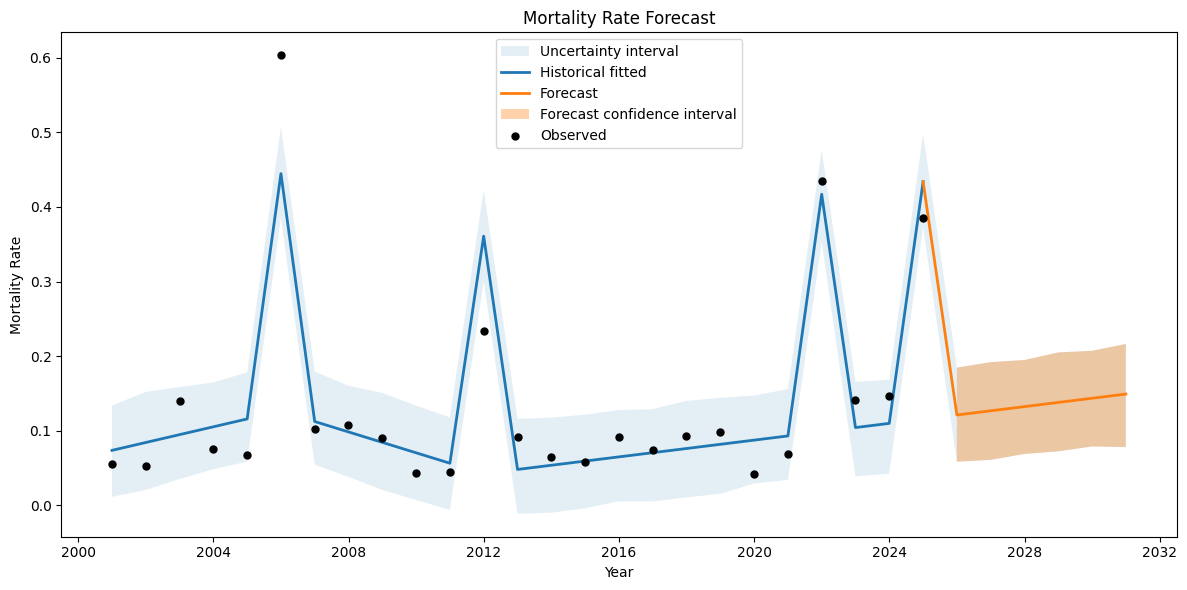

In [17]:
north_america_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

In [18]:
# 1. Xử lý âm yhat_lower và in bảng
cleaned_df = north_america_model.process_and_print_forecast(north_america_forecast)

# 2. Chạy Benchmark 1 (Trung bình)
north_america_model.evaluate_benchmark_mean(cleaned_df)

# 3. Chạy Benchmark 2 (Tốc độ thay đổi)
north_america_model.evaluate_benchmark_yoy(cleaned_df)


 Mortality Rate Forecast (2025-2030) - cắt âm 
           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.121115    0.061631    0.187084
26 2026-12-31  0.126725    0.064674    0.187775
27 2027-12-31  0.132334    0.069533    0.191710
28 2028-12-31  0.137960    0.077016    0.200406
29 2029-12-31  0.143569    0.074010    0.212259
30 2030-12-31  0.149179    0.082112    0.217587
Mean yhat_lower (last 7): 0.071496
Mean yhat_upper (last 7): 0.199470
Historical Mean Mortality Rate: 0.1361
Forecast Mean Mortality Rate (2025-2030): 0.1351
25% Reduction Threshold (Target <= 0.1020)
50% Reduction Threshold (Target <= 0.0680)
No: 25% reduction
No: 50% reduction
Historical Average YoY Change (Benchmark): 0.013722

Forecasted YoY Changes:
           ds      yhat  year_on_year_change
25 2025-12-31  0.121115                  NaN
26 2026-12-31  0.126725             0.005610
27 2027-12-31  0.132334             0.005610
28 2028-12-31  0.137960             0.005625
29 2029-12-31  0.143569           

## 2.3. Country Level

### 2.3.1. Viet Nam

In [19]:
vietnam = prepare_level_data(df,level='country', filter='Viet Nam')
vietnam_model = ProphetModel(vietnam)
best_params = {
    "changepoint_prior_scale": float(0.1),
    "holidays_prior_scale": float(15.0)
}
holiday_years = []
vietnam_forecast = vietnam_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(vietnam_forecast)

23:48:07 - cmdstanpy - INFO - Chain [1] start processing
23:48:07 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.056955   -0.158938    0.270661
26 2026-12-31  0.040974   -0.164196    0.246698
27 2027-12-31  0.024993   -0.179621    0.234017
28 2028-12-31  0.008969   -0.186015    0.227142
29 2029-12-31 -0.007012   -0.233343    0.197877
30 2030-12-31 -0.022993   -0.228361    0.191883


23:48:09 - cmdstanpy - INFO - Chain [1] start processing
23:48:09 - cmdstanpy - INFO - Chain [1] done processing


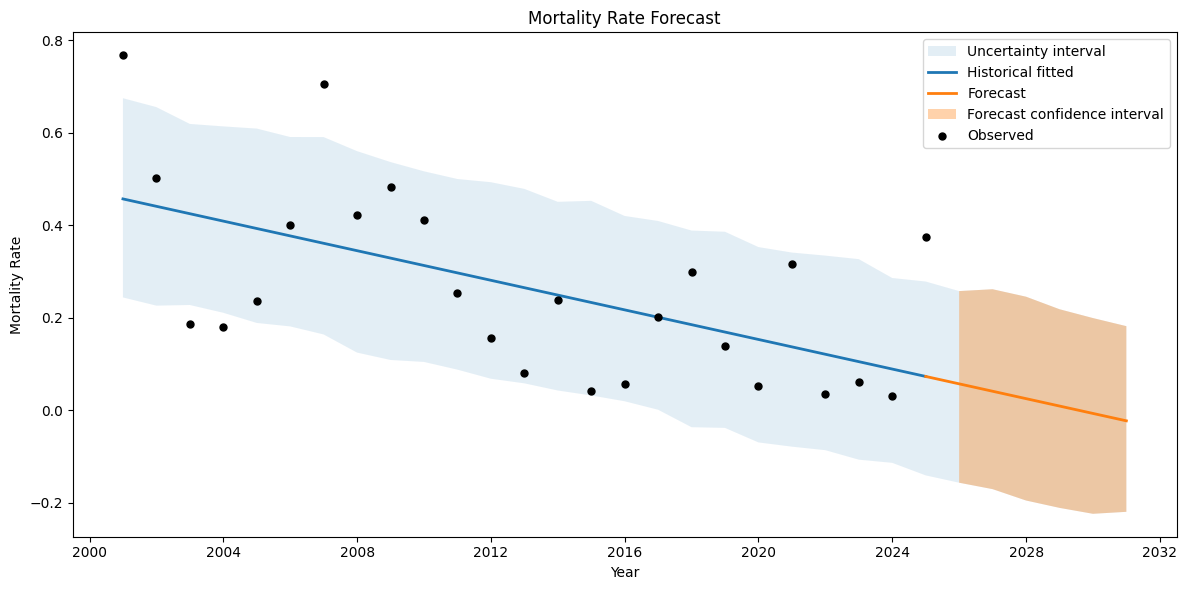

In [20]:
vietnam_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

In [21]:
# 1. Xử lý âm yhat_lower và in bảng
cleaned_df = vietnam_model.process_and_print_forecast(vietnam_forecast)

# 2. Chạy Benchmark 1 (Trung bình)
vietnam_model.evaluate_benchmark_mean(cleaned_df)

# 3. Chạy Benchmark 2 (Tốc độ thay đổi)
vietnam_model.evaluate_benchmark_yoy(cleaned_df)


 Mortality Rate Forecast (2025-2030) - cắt âm 
           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.056955         0.0    0.270661
26 2026-12-31  0.040974         0.0    0.246698
27 2027-12-31  0.024993         0.0    0.234017
28 2028-12-31  0.008969         0.0    0.227142
29 2029-12-31 -0.007012         0.0    0.197877
30 2030-12-31 -0.022993         0.0    0.191883
Mean yhat_lower (last 7): 0.000000
Mean yhat_upper (last 7): 0.228046
Historical Mean Mortality Rate: 0.2650
Forecast Mean Mortality Rate (2025-2030): 0.0170
25% Reduction Threshold (Target <= 0.1987)
50% Reduction Threshold (Target <= 0.1325)
Yes: 25% reduction
Yes: 50% reduction
Historical Average YoY Change (Benchmark): -0.016333

Forecasted YoY Changes:
           ds      yhat  year_on_year_change
25 2025-12-31  0.056955                  NaN
26 2026-12-31  0.040974            -0.015981
27 2027-12-31  0.024993            -0.015981
28 2028-12-31  0.008969            -0.016025
29 2029-12-31 -0.007012        

### 2.3.2. Japan

In [22]:
japan = prepare_level_data(df,level='country', filter='Japan')
japan_model = ProphetModel(japan)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2011]
japan_forecast = japan_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(japan_forecast)

23:48:16 - cmdstanpy - INFO - Chain [1] start processing
23:48:16 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.217020    0.067489    0.372049
26 2026-12-31  0.224105    0.080709    0.385278
27 2027-12-31  0.231189    0.075795    0.372998
28 2028-12-31  0.238292    0.091680    0.389476
29 2029-12-31  0.245377    0.098881    0.390200
30 2030-12-31  0.252461    0.093225    0.393187


23:48:18 - cmdstanpy - INFO - Chain [1] start processing
23:48:18 - cmdstanpy - INFO - Chain [1] done processing


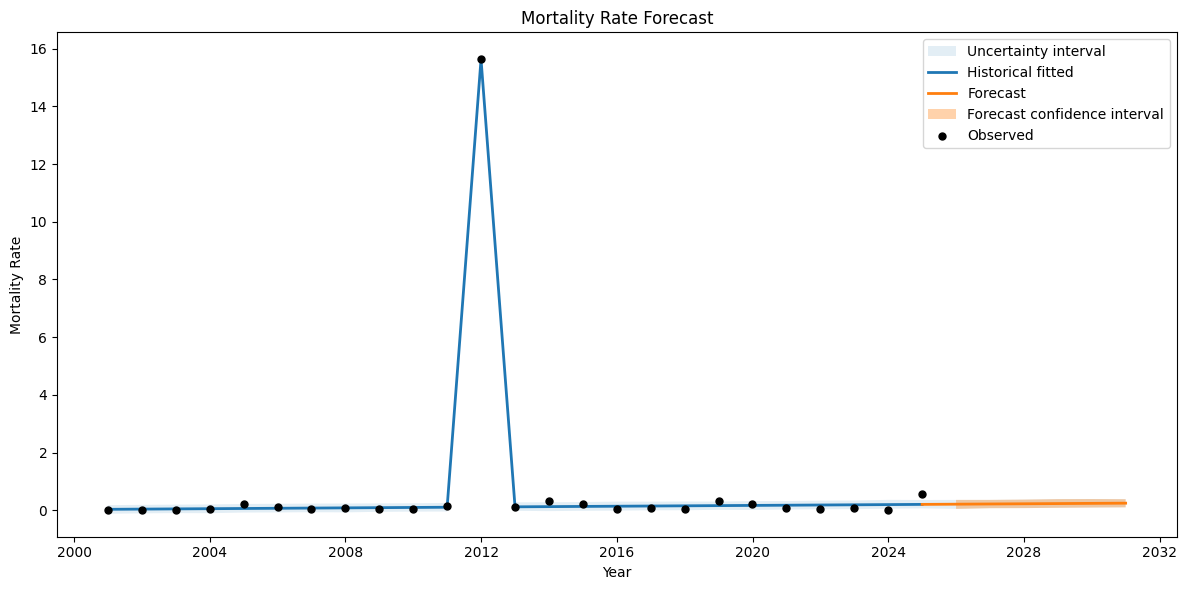

In [23]:
japan_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

In [24]:
# 1. Xử lý âm yhat_lower và in bảng
cleaned_df = japan_model.process_and_print_forecast(japan_forecast)

# 2. Chạy Benchmark 1 (Trung bình)
japan_model.evaluate_benchmark_mean(cleaned_df)

# 3. Chạy Benchmark 2 (Tốc độ thay đổi)
japan_model.evaluate_benchmark_yoy(cleaned_df)


 Mortality Rate Forecast (2025-2030) - cắt âm 
           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.217020    0.067489    0.372049
26 2026-12-31  0.224105    0.080709    0.385278
27 2027-12-31  0.231189    0.075795    0.372998
28 2028-12-31  0.238292    0.091680    0.389476
29 2029-12-31  0.245377    0.098881    0.390200
30 2030-12-31  0.252461    0.093225    0.393187
Mean yhat_lower (last 7): 0.084630
Mean yhat_upper (last 7): 0.383865
Historical Mean Mortality Rate: 0.7454
Forecast Mean Mortality Rate (2025-2030): 0.2347
25% Reduction Threshold (Target <= 0.5591)
50% Reduction Threshold (Target <= 0.3727)
Yes: 25% reduction
Yes: 50% reduction
Historical Average YoY Change (Benchmark): 0.022408

Forecasted YoY Changes:
           ds      yhat  year_on_year_change
25 2025-12-31  0.217020                  NaN
26 2026-12-31  0.224105             0.007084
27 2027-12-31  0.231189             0.007084
28 2028-12-31  0.238292             0.007104
29 2029-12-31  0.245377         

### 2.3.3. France

In [13]:
france = prepare_level_data(df,level='country', filter='France')
france_model = ARIMAModel(france)
france_forecast = france_model.arima_forecast(0, 0, 0, steps=6)
print(france_forecast)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25              2.343283  6.216549      -9.840929      14.527495
26              2.343283  6.216549      -9.840929      14.527495
27              2.343283  6.216549      -9.840929      14.527495
28              2.343283  6.216549      -9.840929      14.527495
29              2.343283  6.216549      -9.840929      14.527495
30              2.343283  6.216549      -9.840929      14.527495


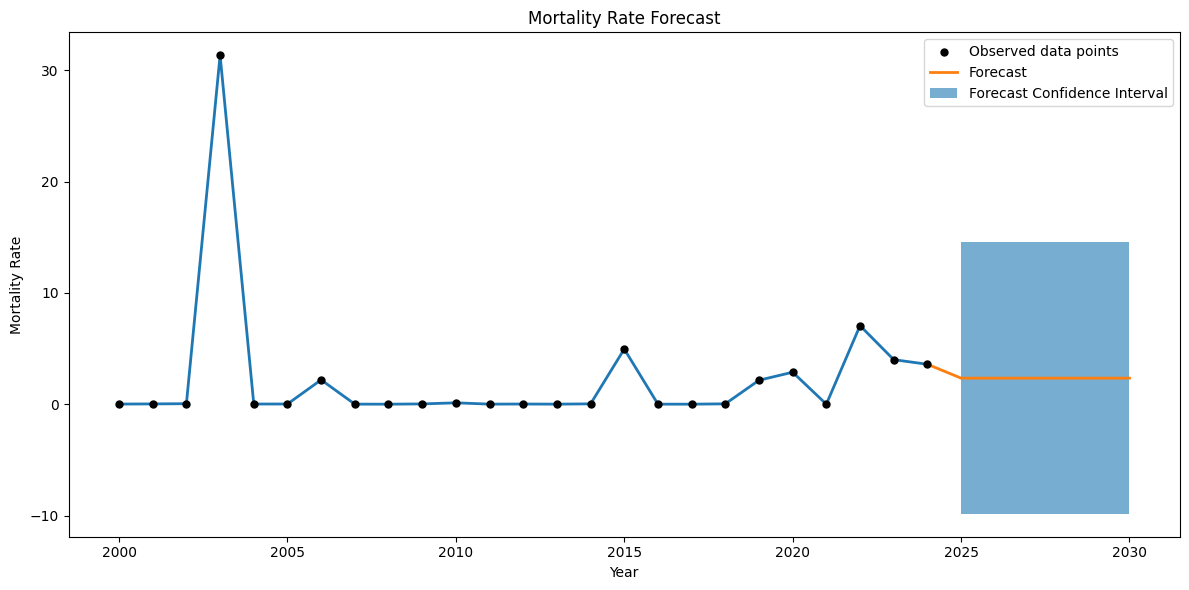

In [14]:
france_model.plot_forecast(0, 0, 0, steps=6)

In [15]:
# Hậu xử lý & Benchmarks dùng hàm arima_...
cleaned_arima = france_model.arima_post_process(france_forecast)
print("============Benchmark 1 (Trung bình)===================")
# 2. Chạy Benchmark 1 (Trung bình)
france_model.arima_mean_strategy(cleaned_arima)

print("============Benchmark 2 (Tốc độ thay đổi)===================")
france_model.arima_yoy_strategy(cleaned_arima)


 Mortality Rate Forecast (2025-2030) - ARIMA Cắt Âm 
Mortality_Rate      mean  mean_ci_lower  mean_ci_upper
25              2.343283            0.0      14.527495
26              2.343283            0.0      14.527495
27              2.343283            0.0      14.527495
28              2.343283            0.0      14.527495
29              2.343283            0.0      14.527495
30              2.343283            0.0      14.527495
Mean mean_ci_lower (last 6): 0.000000
Mean mean_ci_upper (last 6): 14.527495
============Benchmark 1 (Trung bình)===================
Historical Mean Mortality Rate: 2.3433
Forecast Mean Mortality Rate (2025-2030): 2.3433
25% Reduction Threshold (Target <= 1.7575)
50% Reduction Threshold (Target <= 1.1716)
No: 25% reduction
No: 50% reduction
============Benchmark 2 (Tốc độ thay đổi)===================
Historical Average YoY Change (Benchmark): 0.148907

Forecasted YoY Changes (ARIMA):
        mean  year_on_year_change
25  2.343283            -1.245252
26  

### 2.3.4. Italy

In [25]:
italy = prepare_level_data(df,level='country', filter='Italy')
italy_model = ProphetModel(italy)
best_params = {
    "changepoint_prior_scale": float(0.1),
    "holidays_prior_scale": float(10.0)
}
holiday_years = [2003,2022,2023,2024]
italy_forecast = italy_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(italy_forecast)

23:48:28 - cmdstanpy - INFO - Chain [1] start processing
23:48:28 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31 -1.169082   -3.564084    1.540522
26 2026-12-31 -1.257345   -3.604080    1.343700
27 2027-12-31 -1.345607   -3.630949    1.143401
28 2028-12-31 -1.434111   -3.796598    1.239045
29 2029-12-31 -1.522374   -3.893508    0.965418
30 2030-12-31 -1.610636   -4.019397    0.713572


23:48:30 - cmdstanpy - INFO - Chain [1] start processing
23:48:30 - cmdstanpy - INFO - Chain [1] done processing


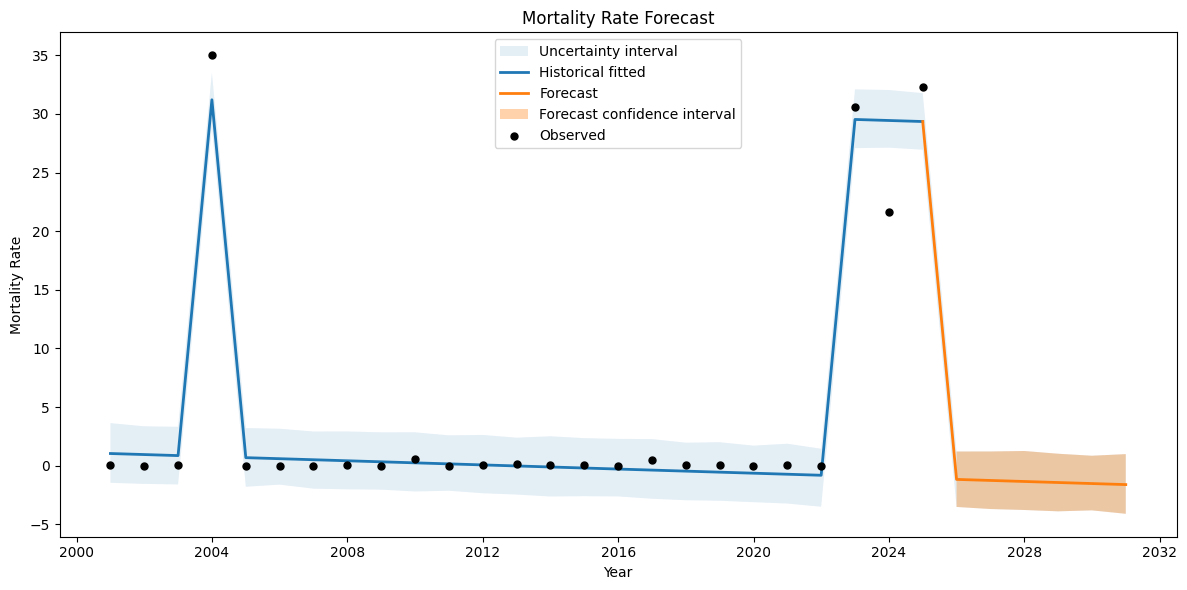

In [26]:
italy_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

In [27]:
# 1. Xử lý âm yhat_lower và in bảng
cleaned_df = italy_model.process_and_print_forecast(italy_forecast)

# 2. Chạy Benchmark 1 (Trung bình)
italy_model.evaluate_benchmark_mean(cleaned_df)

# 3. Chạy Benchmark 2 (Tốc độ thay đổi)
italy_model.evaluate_benchmark_yoy(cleaned_df)


 Mortality Rate Forecast (2025-2030) - cắt âm 
           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31 -1.169082         0.0    1.540522
26 2026-12-31 -1.257345         0.0    1.343700
27 2027-12-31 -1.345607         0.0    1.143401
28 2028-12-31 -1.434111         0.0    1.239045
29 2029-12-31 -1.522374         0.0    0.965418
30 2030-12-31 -1.610636         0.0    0.713572
Mean yhat_lower (last 7): 0.000000
Mean yhat_upper (last 7): 1.157610
Historical Mean Mortality Rate: 4.8485
Forecast Mean Mortality Rate (2025-2030): -1.3899
25% Reduction Threshold (Target <= 3.6364)
50% Reduction Threshold (Target <= 2.4243)
Yes: 25% reduction
Yes: 50% reduction
Historical Average YoY Change (Benchmark): 1.342633

Forecasted YoY Changes:
           ds      yhat  year_on_year_change
25 2025-12-31 -1.169082                  NaN
26 2026-12-31 -1.257345            -0.088262
27 2027-12-31 -1.345607            -0.088262
28 2028-12-31 -1.434111            -0.088504
29 2029-12-31 -1.522374        

### 2.3.5. Mexico

In [28]:
mexico = prepare_level_data(df,level='country', filter='Mexico')
mexico_model = ProphetModel(mexico)
best_params = {
    "changepoint_prior_scale": float(0.1),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2000,2013,2017, 2024]
mexico_forecast = mexico_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(mexico_forecast)

23:48:39 - cmdstanpy - INFO - Chain [1] start processing
23:48:39 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.046040   -0.015298    0.109368
26 2026-12-31  0.045307   -0.018379    0.107963
27 2027-12-31  0.044574   -0.017350    0.103477
28 2028-12-31  0.043839   -0.020585    0.102813
29 2029-12-31  0.043106   -0.016009    0.107745
30 2030-12-31  0.042373   -0.024583    0.102549


23:48:41 - cmdstanpy - INFO - Chain [1] start processing
23:48:42 - cmdstanpy - INFO - Chain [1] done processing


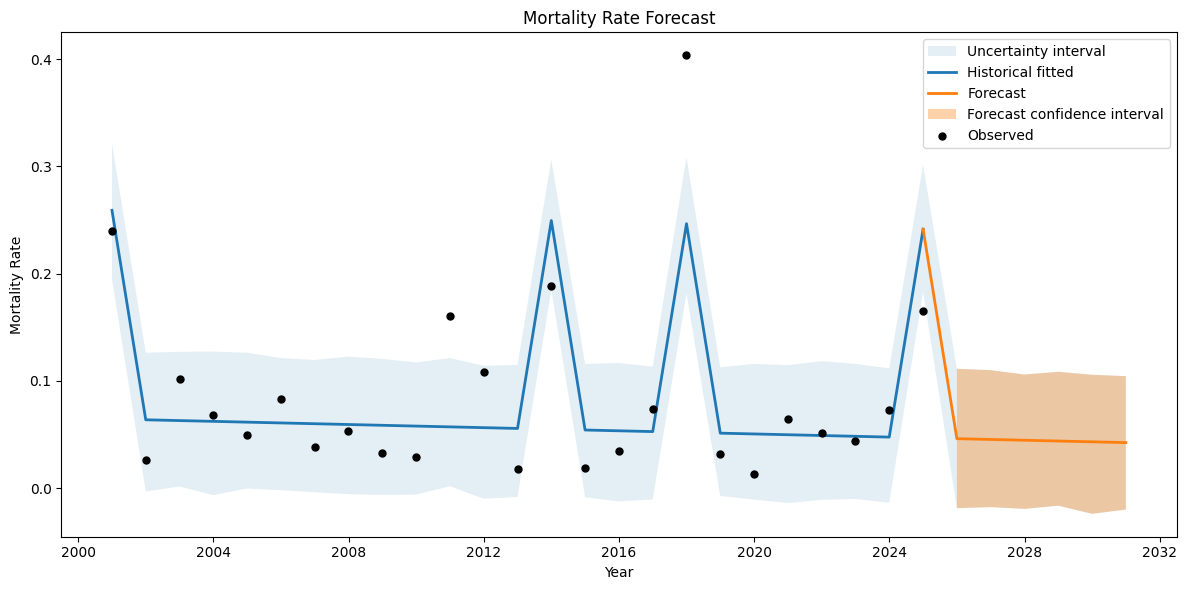

In [29]:
mexico_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

In [30]:
# 1. Xử lý âm yhat_lower và in bảng
cleaned_df = mexico_model.process_and_print_forecast(mexico_forecast)

# 2. Chạy Benchmark 1 (Trung bình)
mexico_model.evaluate_benchmark_mean(cleaned_df)

# 3. Chạy Benchmark 2 (Tốc độ thay đổi)
mexico_model.evaluate_benchmark_yoy(cleaned_df)


 Mortality Rate Forecast (2025-2030) - cắt âm 
           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.046040         0.0    0.109368
26 2026-12-31  0.045307         0.0    0.107963
27 2027-12-31  0.044574         0.0    0.103477
28 2028-12-31  0.043839         0.0    0.102813
29 2029-12-31  0.043106         0.0    0.107745
30 2030-12-31  0.042373         0.0    0.102549
Mean yhat_lower (last 7): 0.000000
Mean yhat_upper (last 7): 0.105652
Historical Mean Mortality Rate: 0.0867
Forecast Mean Mortality Rate (2025-2030): 0.0442
25% Reduction Threshold (Target <= 0.0650)
50% Reduction Threshold (Target <= 0.0434)
Yes: 25% reduction
No: 50% reduction
Historical Average YoY Change (Benchmark): -0.003093

Forecasted YoY Changes:
           ds      yhat  year_on_year_change
25 2025-12-31  0.046040                  NaN
26 2026-12-31  0.045307            -0.000733
27 2027-12-31  0.044574            -0.000733
28 2028-12-31  0.043839            -0.000735
29 2029-12-31  0.043106         

### 2.3.6. Sudan

In [31]:
sudan = prepare_level_data(df,level='country', filter='Sudan')
sudan_model = ProphetModel(sudan)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2005, 2006, 2007, 2017, 2024]
sudan_forecast = sudan_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(sudan_forecast)

23:48:48 - cmdstanpy - INFO - Chain [1] start processing
23:48:48 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.218265   -0.271402    0.708335
26 2026-12-31  0.217968   -0.280415    0.732693
27 2027-12-31  0.217672   -0.256293    0.712535
28 2028-12-31  0.217375   -0.248716    0.746135
29 2029-12-31  0.217079   -0.245526    0.686730
30 2030-12-31  0.216783   -0.236614    0.705626


23:48:51 - cmdstanpy - INFO - Chain [1] start processing
23:48:51 - cmdstanpy - INFO - Chain [1] done processing


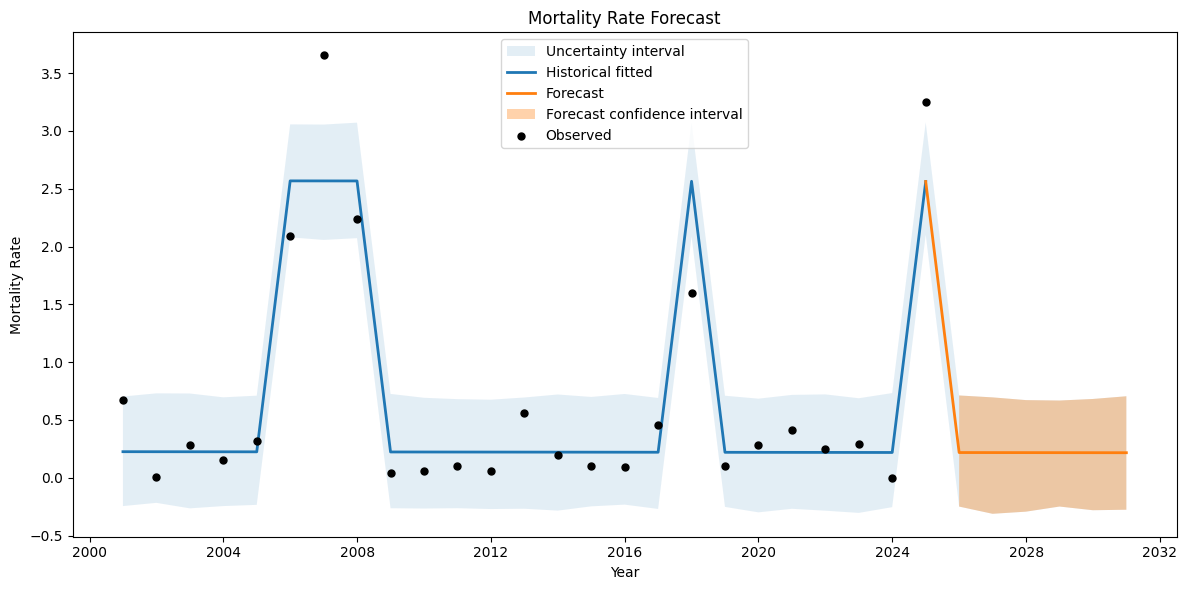

In [32]:
sudan_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

In [33]:
# 1. Xử lý âm yhat_lower và in bảng
cleaned_df = sudan_model.process_and_print_forecast(sudan_forecast)

# 2. Chạy Benchmark 1 (Trung bình)
sudan_model.evaluate_benchmark_mean(cleaned_df)

# 3. Chạy Benchmark 2 (Tốc độ thay đổi)
sudan_model.evaluate_benchmark_yoy(cleaned_df)


 Mortality Rate Forecast (2025-2030) - cắt âm 
           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.218265         0.0    0.708335
26 2026-12-31  0.217968         0.0    0.732693
27 2027-12-31  0.217672         0.0    0.712535
28 2028-12-31  0.217375         0.0    0.746135
29 2029-12-31  0.217079         0.0    0.686730
30 2030-12-31  0.216783         0.0    0.705626
Mean yhat_lower (last 7): 0.000000
Mean yhat_upper (last 7): 0.715342
Historical Mean Mortality Rate: 0.6918
Forecast Mean Mortality Rate (2025-2030): 0.2175
25% Reduction Threshold (Target <= 0.5189)
50% Reduction Threshold (Target <= 0.3459)
Yes: 25% reduction
Yes: 50% reduction
Historical Average YoY Change (Benchmark): 0.107590

Forecasted YoY Changes:
           ds      yhat  year_on_year_change
25 2025-12-31  0.218265                  NaN
26 2026-12-31  0.217968            -0.000296
27 2027-12-31  0.217672            -0.000296
28 2028-12-31  0.217375            -0.000297
29 2029-12-31  0.217079         

### 2.3.7. Türkiye

In [16]:
turkey = prepare_level_data(df,level='country', filter='Türkiye')
turkey_model = ARIMAModel(turkey)
turkey_forecast = turkey_model.arima_forecast(0, 0, 0, steps=6)
print(turkey_forecast)


Mortality_Rate      mean    mean_se  mean_ci_lower  mean_ci_upper
25              2.580184  12.167329     -21.267343      26.427711
26              2.580184  12.167329     -21.267343      26.427711
27              2.580184  12.167329     -21.267343      26.427711
28              2.580184  12.167329     -21.267343      26.427711
29              2.580184  12.167329     -21.267343      26.427711
30              2.580184  12.167329     -21.267343      26.427711


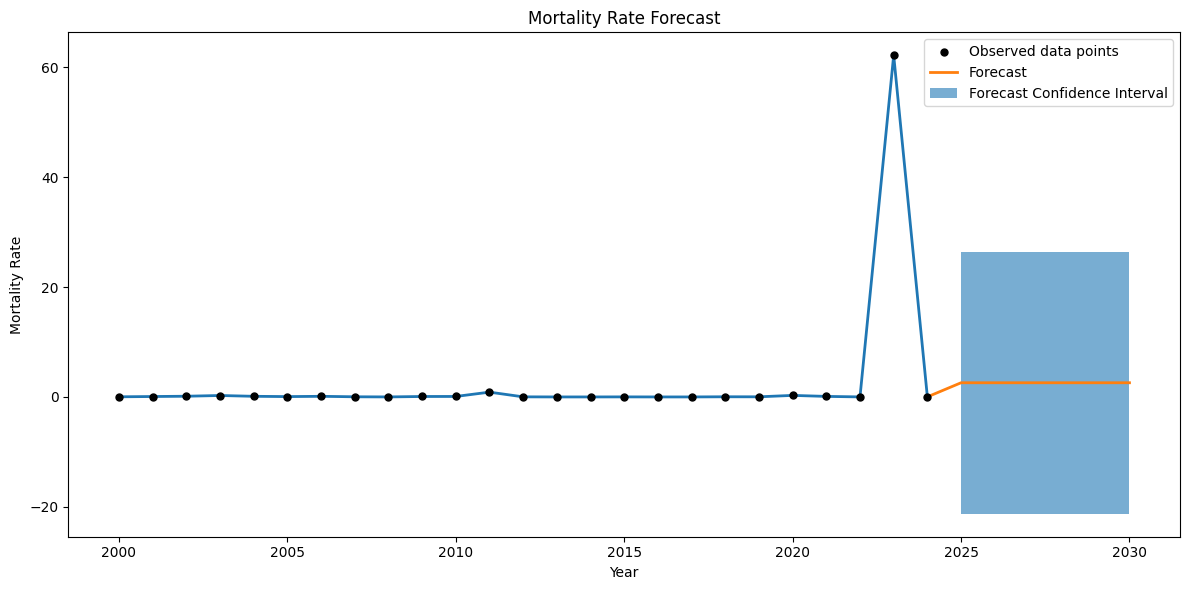

In [17]:
turkey_model.plot_forecast(0, 0, 0, steps=6)

In [18]:
# Hậu xử lý & Benchmarks dùng hàm arima_...
cleaned_arima = turkey_model.arima_post_process(turkey_forecast)
print("============Benchmark 1 (Trung bình)===================")
# 2. Chạy Benchmark 1 (Trung bình)
turkey_model.arima_mean_strategy(cleaned_arima)

print("============Benchmark 2 (Tốc độ thay đổi)===================")
turkey_model.arima_yoy_strategy(cleaned_arima)


 Mortality Rate Forecast (2025-2030) - ARIMA Cắt Âm 
Mortality_Rate      mean  mean_ci_lower  mean_ci_upper
25              2.580184            0.0      26.427711
26              2.580184            0.0      26.427711
27              2.580184            0.0      26.427711
28              2.580184            0.0      26.427711
29              2.580184            0.0      26.427711
30              2.580184            0.0      26.427711
Mean mean_ci_lower (last 6): 0.000000
Mean mean_ci_upper (last 6): 26.427711
============Benchmark 1 (Trung bình)===================
Historical Mean Mortality Rate: 2.5802
Forecast Mean Mortality Rate (2025-2030): 2.5802
25% Reduction Threshold (Target <= 1.9351)
50% Reduction Threshold (Target <= 1.2901)
No: 25% reduction
No: 50% reduction
============Benchmark 2 (Tốc độ thay đổi)===================
Historical Average YoY Change (Benchmark): -0.000532

Forecasted YoY Changes (ARIMA):
        mean  year_on_year_change
25  2.580184              2.56849
26 

### 2.3.8. Canada

In [34]:
canada = prepare_level_data(df,level='country', filter='Canada')
canada_model = ProphetModel(canada)
best_params = {
    "changepoint_prior_scale": float(0.2),
    "holidays_prior_scale": float(15.0)}
holiday_years = [2018,2021]
canada_forecast = canada_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(canada_forecast)

23:49:01 - cmdstanpy - INFO - Chain [1] start processing
23:49:01 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.043866   -0.302210    0.392141
26 2026-12-31  0.046153   -0.304343    0.414534
27 2027-12-31  0.048441   -0.297460    0.377621
28 2028-12-31  0.050735   -0.289312    0.387119
29 2029-12-31  0.053023   -0.311377    0.408586
30 2030-12-31  0.055310   -0.283963    0.419628


23:49:04 - cmdstanpy - INFO - Chain [1] start processing
23:49:04 - cmdstanpy - INFO - Chain [1] done processing


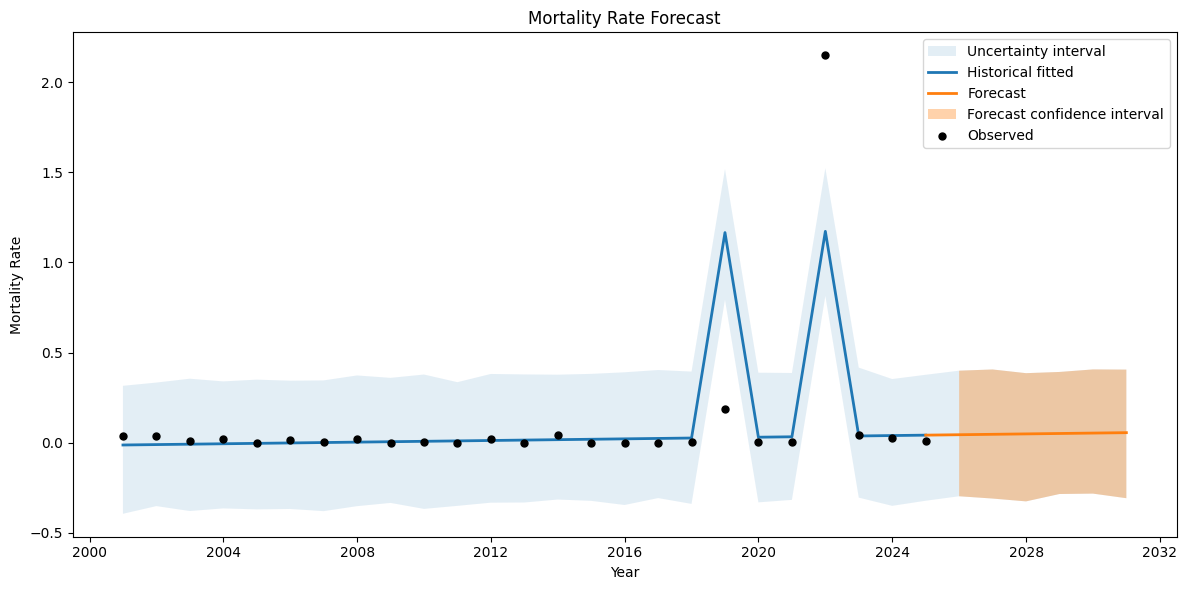

In [35]:
canada_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

In [36]:
# 1. Xử lý âm yhat_lower và in bảng
cleaned_df = canada_model.process_and_print_forecast(canada_forecast)

# 2. Chạy Benchmark 1 (Trung bình)
canada_model.evaluate_benchmark_mean(cleaned_df)

# 3. Chạy Benchmark 2 (Tốc độ thay đổi)
canada_model.evaluate_benchmark_yoy(cleaned_df)


 Mortality Rate Forecast (2025-2030) - cắt âm 
           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.043866         0.0    0.392141
26 2026-12-31  0.046153         0.0    0.414534
27 2027-12-31  0.048441         0.0    0.377621
28 2028-12-31  0.050735         0.0    0.387119
29 2029-12-31  0.053023         0.0    0.408586
30 2030-12-31  0.055310         0.0    0.419628
Mean yhat_lower (last 7): 0.000000
Mean yhat_upper (last 7): 0.399938
Historical Mean Mortality Rate: 0.1052
Forecast Mean Mortality Rate (2025-2030): 0.0496
25% Reduction Threshold (Target <= 0.0789)
50% Reduction Threshold (Target <= 0.0526)
Yes: 25% reduction
Yes: 50% reduction
Historical Average YoY Change (Benchmark): -0.001191

Forecasted YoY Changes:
           ds      yhat  year_on_year_change
25 2025-12-31  0.043866                  NaN
26 2026-12-31  0.046153             0.002288
27 2027-12-31  0.048441             0.002288
28 2028-12-31  0.050735             0.002294
29 2029-12-31  0.053023        

### 2.3.9. United States of America

In [19]:
america = prepare_level_data(df,level='country', filter='United States of America')
america_model = ARIMAModel(america)
america_forecast = america_model.arima_forecast(1, 1, 0, steps=6)
print(america_forecast)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25              0.306358  0.168145      -0.023200       0.635916
26              0.363364  0.191143      -0.011270       0.737997
27              0.337176  0.229149      -0.111947       0.786299
28              0.349206  0.254220      -0.149055       0.847467
29              0.343679  0.280091      -0.205289       0.892648
30              0.346218  0.302452      -0.246577       0.939014


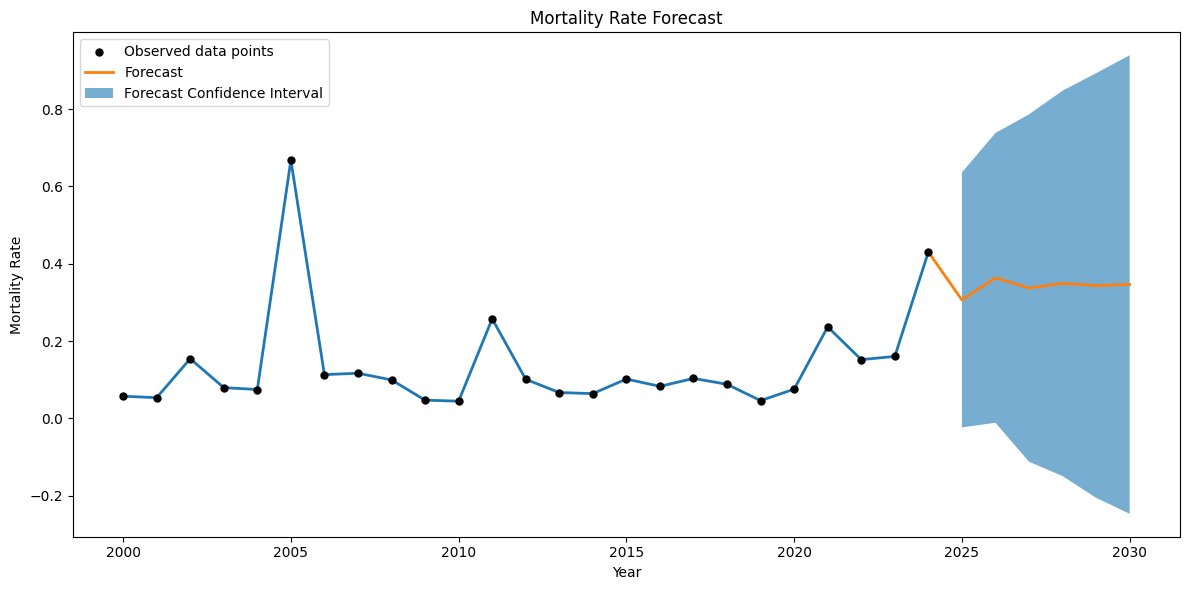

In [20]:
america_model.plot_forecast(1, 1, 0, steps=6)

In [21]:
# Hậu xử lý & Benchmarks dùng hàm arima_...
cleaned_arima = america_model.arima_post_process(america_forecast)
print("============Benchmark 1 (Trung bình)===================")
# 2. Chạy Benchmark 1 (Trung bình)
america_model.arima_mean_strategy(cleaned_arima)

print("============Benchmark 2 (Tốc độ thay đổi)===================")
america_model.arima_yoy_strategy(cleaned_arima)


 Mortality Rate Forecast (2025-2030) - ARIMA Cắt Âm 
Mortality_Rate      mean  mean_ci_lower  mean_ci_upper
25              0.306358            0.0       0.635916
26              0.363364            0.0       0.737997
27              0.337176            0.0       0.786299
28              0.349206            0.0       0.847467
29              0.343679            0.0       0.892648
30              0.346218            0.0       0.939014
Mean mean_ci_lower (last 6): 0.000000
Mean mean_ci_upper (last 6): 0.806557
============Benchmark 1 (Trung bình)===================
Historical Mean Mortality Rate: 0.1391
Forecast Mean Mortality Rate (2025-2030): 0.3410
25% Reduction Threshold (Target <= 0.1043)
50% Reduction Threshold (Target <= 0.0695)
No: 25% reduction
No: 50% reduction
============Benchmark 2 (Tốc độ thay đổi)===================
Historical Average YoY Change (Benchmark): 0.015543

Forecasted YoY Changes (ARIMA):
        mean  year_on_year_change
25  0.306358            -0.124090
26  0

### 2.3.10. India

In [22]:
india = prepare_level_data(df,level='country', filter='India')
india_model = ARIMAModel(india)
india_forecast = india_model.arima_forecast(1, 1, 1, steps=6)
print(india_forecast)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25              0.152911  0.434763      -0.699210       1.005031
26              0.136374  0.434797      -0.715811       0.988560
27              0.141950  0.459991      -0.759616       1.043515
28              0.140070  0.471021      -0.783114       1.063253
29              0.140704  0.485526      -0.810909       1.092317
30              0.140490  0.498331      -0.836221       1.117201


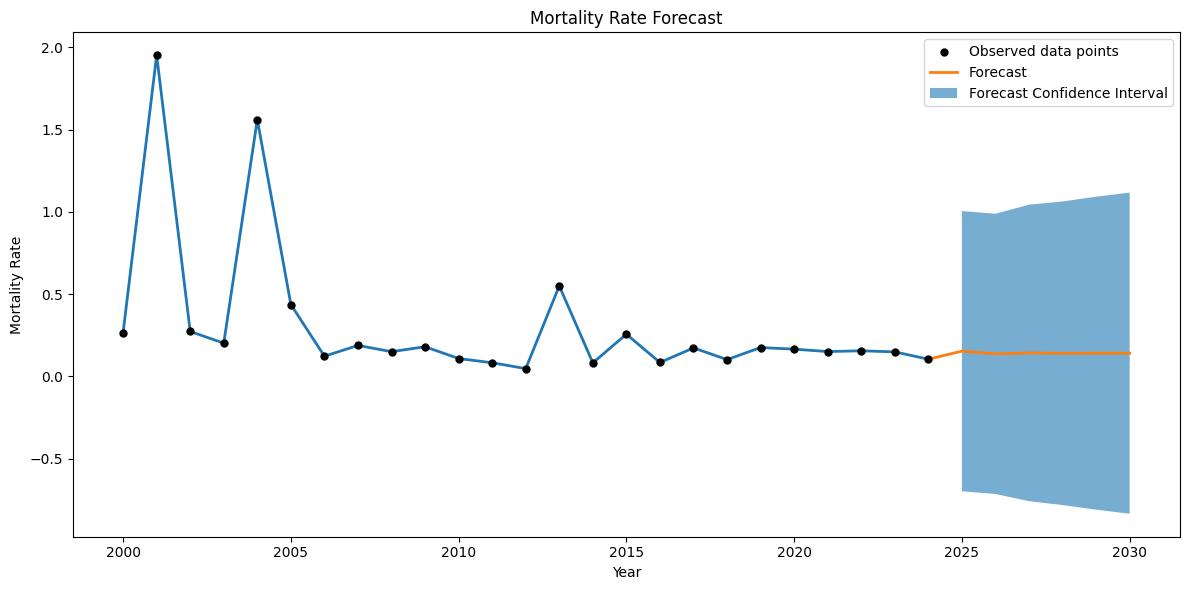

In [23]:
india_model.plot_forecast(1, 1, 1, steps=6)

In [24]:
# Hậu xử lý & Benchmarks dùng hàm arima_...
cleaned_arima = india_model.arima_post_process(india_forecast)
print("============Benchmark 1 (Trung bình)===================")
# 2. Chạy Benchmark 1 (Trung bình)
india_model.arima_mean_strategy(cleaned_arima)

print("============Benchmark 2 (Tốc độ thay đổi)===================")
india_model.arima_yoy_strategy(cleaned_arima)


 Mortality Rate Forecast (2025-2030) - ARIMA Cắt Âm 
Mortality_Rate      mean  mean_ci_lower  mean_ci_upper
25              0.152911            0.0       1.005031
26              0.136374            0.0       0.988560
27              0.141950            0.0       1.043515
28              0.140070            0.0       1.063253
29              0.140704            0.0       1.092317
30              0.140490            0.0       1.117201
Mean mean_ci_lower (last 6): 0.000000
Mean mean_ci_upper (last 6): 1.051646
============Benchmark 1 (Trung bình)===================
Historical Mean Mortality Rate: 0.3084
Forecast Mean Mortality Rate (2025-2030): 0.1421
25% Reduction Threshold (Target <= 0.2313)
50% Reduction Threshold (Target <= 0.1542)
Yes: 25% reduction
Yes: 50% reduction
============Benchmark 2 (Tốc độ thay đổi)===================
Historical Average YoY Change (Benchmark): -0.006740

Forecasted YoY Changes (ARIMA):
        mean  year_on_year_change
25  0.152911             0.049047
26

### 2.3.11. Pakistan

In [25]:
pakistan = prepare_level_data(df,level='country', filter='Pakistan')
pakistan_model = ARIMAModel(pakistan)
pakistan_forecast = pakistan_model.arima_forecast(1, 1, 0, steps=6)
print(pakistan_forecast)

Mortality_Rate      mean    mean_se  mean_ci_lower  mean_ci_upper
25              0.295856  10.500717     -20.285170      20.876883
26              0.361395  11.804970     -22.775921      23.498712
27              0.329521  14.191978     -27.486246      28.145287
28              0.345023  15.681032     -30.389235      31.079281
29              0.337483  17.278861     -33.528462      34.203429
30              0.341150  18.632174     -36.177240      36.859541


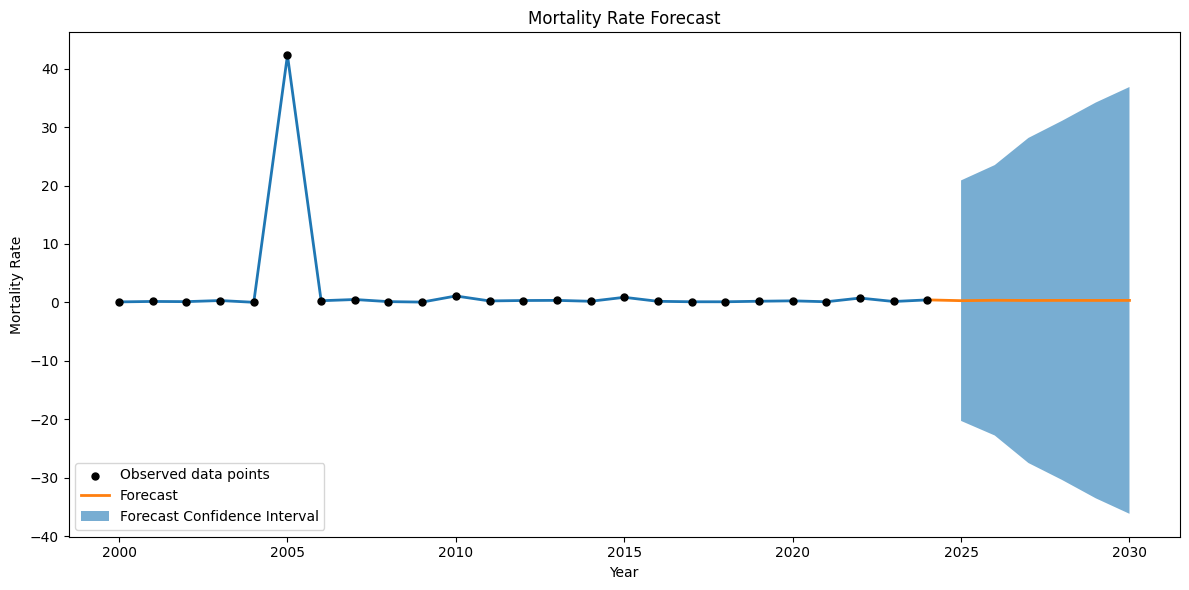

In [26]:
pakistan_model.plot_forecast(1, 1, 0, steps=6)

In [27]:
# Hậu xử lý & Benchmarks dùng hàm arima_...
cleaned_arima = pakistan_model.arima_post_process(pakistan_forecast)
print("============Benchmark 1 (Trung bình)===================")
# 2. Chạy Benchmark 1 (Trung bình)
pakistan_model.arima_mean_strategy(cleaned_arima)

print("============Benchmark 2 (Tốc độ thay đổi)===================")
pakistan_model.arima_yoy_strategy(cleaned_arima)


 Mortality Rate Forecast (2025-2030) - ARIMA Cắt Âm 
Mortality_Rate      mean  mean_ci_lower  mean_ci_upper
25              0.295856            0.0      20.876883
26              0.361395            0.0      23.498712
27              0.329521            0.0      28.145287
28              0.345023            0.0      31.079281
29              0.337483            0.0      34.203429
30              0.341150            0.0      36.859541
Mean mean_ci_lower (last 6): 0.000000
Mean mean_ci_upper (last 6): 29.110522
============Benchmark 1 (Trung bình)===================
Historical Mean Mortality Rate: 1.9739
Forecast Mean Mortality Rate (2025-2030): 0.3351
25% Reduction Threshold (Target <= 1.4804)
50% Reduction Threshold (Target <= 0.9870)
Yes: 25% reduction
Yes: 50% reduction
============Benchmark 2 (Tốc độ thay đổi)===================
Historical Average YoY Change (Benchmark): 0.014364

Forecasted YoY Changes (ARIMA):
        mean  year_on_year_change
25  0.295856            -0.134758
26

### 2.3.12. South Africa

In [37]:
south_africa = prepare_level_data(df,level='country', filter='South Africa')
south_africa_model = ProphetModel(south_africa)
best_params = {
    "changepoint_prior_scale": float(0.1),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2000,2002,2022]
south_africa_forecast = south_africa_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(south_africa_forecast)

23:49:21 - cmdstanpy - INFO - Chain [1] start processing
23:49:22 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.150038    0.030494    0.276780
26 2026-12-31  0.156912    0.038261    0.279548
27 2027-12-31  0.163786    0.033908    0.287856
28 2028-12-31  0.170680    0.041643    0.289639
29 2029-12-31  0.177554    0.056141    0.291738
30 2030-12-31  0.184428    0.057516    0.308200


23:49:24 - cmdstanpy - INFO - Chain [1] start processing
23:49:24 - cmdstanpy - INFO - Chain [1] done processing


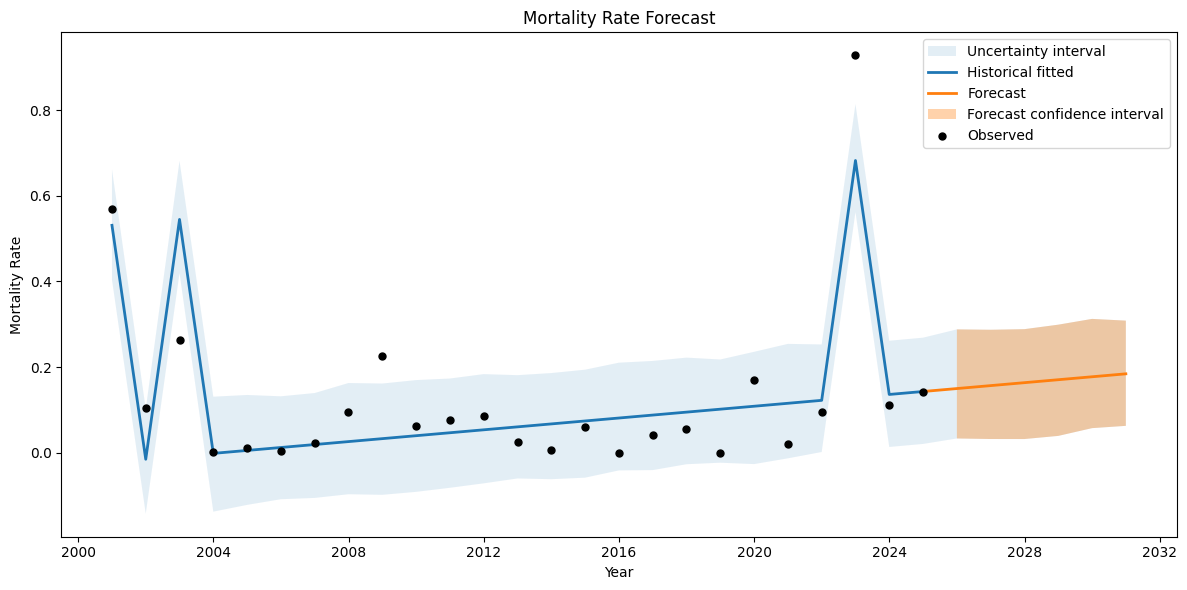

In [38]:
south_africa_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

In [39]:
# 1. Xử lý âm yhat_lower và in bảng
cleaned_df = south_africa_model.process_and_print_forecast(south_africa_forecast)

# 2. Chạy Benchmark 1 (Trung bình)
south_africa_model.evaluate_benchmark_mean(cleaned_df)

# 3. Chạy Benchmark 2 (Tốc độ thay đổi)
south_africa_model.evaluate_benchmark_yoy(cleaned_df)


 Mortality Rate Forecast (2025-2030) - cắt âm 
           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.150038    0.030494    0.276780
26 2026-12-31  0.156912    0.038261    0.279548
27 2027-12-31  0.163786    0.033908    0.287856
28 2028-12-31  0.170680    0.041643    0.289639
29 2029-12-31  0.177554    0.056141    0.291738
30 2030-12-31  0.184428    0.057516    0.308200
Mean yhat_lower (last 7): 0.042994
Mean yhat_upper (last 7): 0.288960
Historical Mean Mortality Rate: 0.1271
Forecast Mean Mortality Rate (2025-2030): 0.1672
25% Reduction Threshold (Target <= 0.0953)
50% Reduction Threshold (Target <= 0.0635)
No: 25% reduction
No: 50% reduction
Historical Average YoY Change (Benchmark): -0.017755

Forecasted YoY Changes:
           ds      yhat  year_on_year_change
25 2025-12-31  0.150038                  NaN
26 2026-12-31  0.156912             0.006874
27 2027-12-31  0.163786             0.006874
28 2028-12-31  0.170680             0.006893
29 2029-12-31  0.177554          

### 2.3.13. Kenya

In [28]:
kenya = prepare_level_data(df,level='country', filter='Kenya')
kenya_model = ARIMAModel(kenya)
kenya_forecast = kenya_model.arima_forecast(0, 0, 0, steps=6)

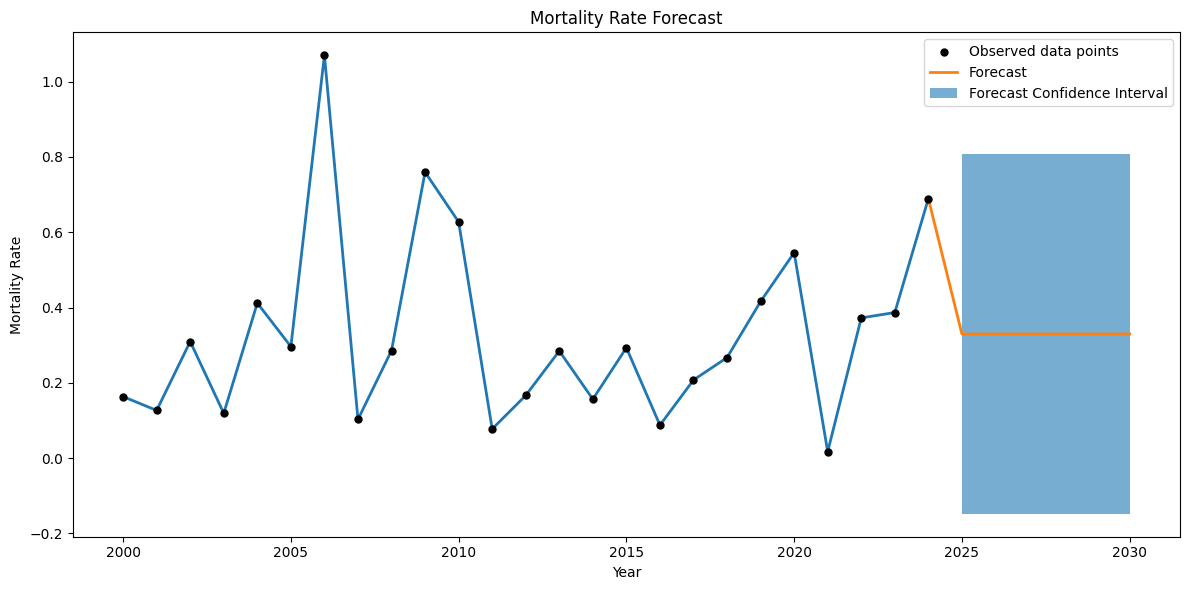

In [29]:
kenya_model.plot_forecast(0, 0, 0, steps=6)

In [30]:
# Hậu xử lý & Benchmarks dùng hàm arima_...
cleaned_arima = kenya_model.arima_post_process(kenya_forecast)
print("============Benchmark 1 (Trung bình)===================")
# 2. Chạy Benchmark 1 (Trung bình)
kenya_model.arima_mean_strategy(cleaned_arima)

print("============Benchmark 2 (Tốc độ thay đổi)===================")
kenya_model.arima_yoy_strategy(cleaned_arima)


 Mortality Rate Forecast (2025-2030) - ARIMA Cắt Âm 
Mortality_Rate      mean  mean_ci_lower  mean_ci_upper
25              0.329507            0.0       0.807247
26              0.329507            0.0       0.807247
27              0.329507            0.0       0.807247
28              0.329507            0.0       0.807247
29              0.329507            0.0       0.807247
30              0.329507            0.0       0.807247
Mean mean_ci_lower (last 6): 0.000000
Mean mean_ci_upper (last 6): 0.807247
============Benchmark 1 (Trung bình)===================
Historical Mean Mortality Rate: 0.3295
Forecast Mean Mortality Rate (2025-2030): 0.3295
25% Reduction Threshold (Target <= 0.2471)
50% Reduction Threshold (Target <= 0.1648)
No: 25% reduction
No: 50% reduction
============Benchmark 2 (Tốc độ thay đổi)===================
Historical Average YoY Change (Benchmark): 0.021923

Forecasted YoY Changes (ARIMA):
        mean  year_on_year_change
25  0.329507            -0.359806
26  0

### 2.3.14. Brazil

In [40]:
brazil = prepare_level_data(df,level='country', filter='Brazil')
brazil_model = ProphetModel(brazil)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2011]
brazil_forecast = brazil_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(brazil_forecast)

23:49:35 - cmdstanpy - INFO - Chain [1] start processing
23:49:36 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.092598    0.013457    0.174185
26 2026-12-31  0.093814    0.011521    0.176503
27 2027-12-31  0.095030    0.014286    0.175707
28 2028-12-31  0.096249    0.021402    0.176995
29 2029-12-31  0.097465    0.018075    0.180143
30 2030-12-31  0.098682    0.018970    0.176611


23:49:38 - cmdstanpy - INFO - Chain [1] start processing
23:49:38 - cmdstanpy - INFO - Chain [1] done processing


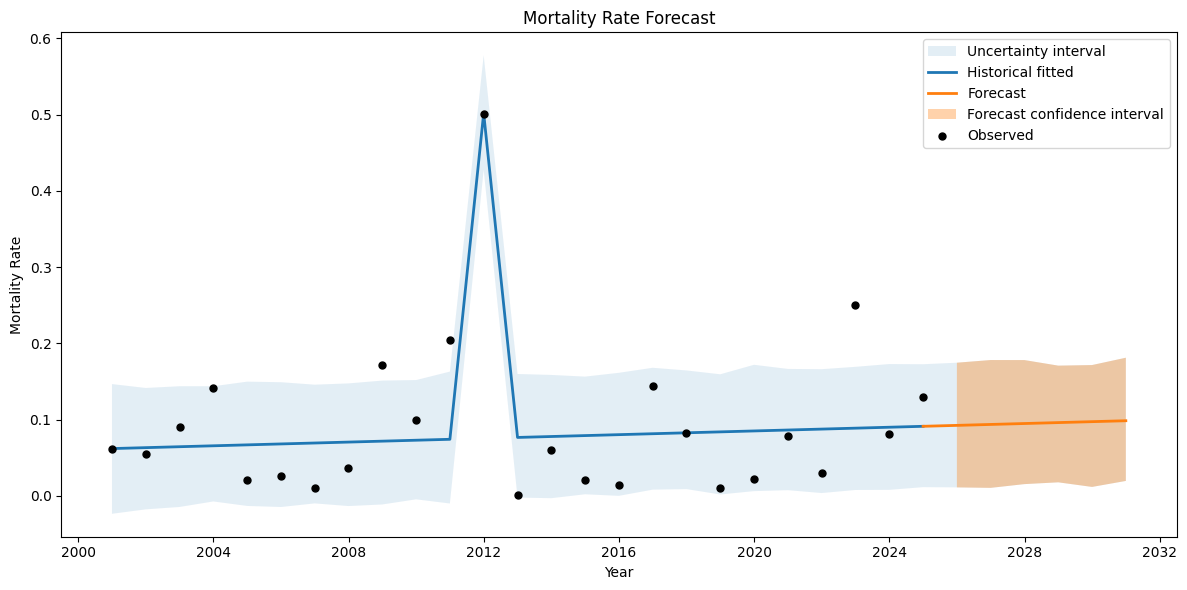

In [41]:
brazil_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

In [42]:
# 1. Xử lý âm yhat_lower và in bảng
cleaned_df = brazil_model.process_and_print_forecast(brazil_forecast)

# 2. Chạy Benchmark 1 (Trung bình)
brazil_model.evaluate_benchmark_mean(cleaned_df)

# 3. Chạy Benchmark 2 (Tốc độ thay đổi)
brazil_model.evaluate_benchmark_yoy(cleaned_df)


 Mortality Rate Forecast (2025-2030) - cắt âm 
           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.092598    0.013457    0.174185
26 2026-12-31  0.093814    0.011521    0.176503
27 2027-12-31  0.095030    0.014286    0.175707
28 2028-12-31  0.096249    0.021402    0.176995
29 2029-12-31  0.097465    0.018075    0.180143
30 2030-12-31  0.098682    0.018970    0.176611
Mean yhat_lower (last 7): 0.016285
Mean yhat_upper (last 7): 0.176691
Historical Mean Mortality Rate: 0.0939
Forecast Mean Mortality Rate (2025-2030): 0.0956
25% Reduction Threshold (Target <= 0.0704)
50% Reduction Threshold (Target <= 0.0469)
No: 25% reduction
No: 50% reduction
Historical Average YoY Change (Benchmark): 0.002819

Forecasted YoY Changes:
           ds      yhat  year_on_year_change
25 2025-12-31  0.092598                  NaN
26 2026-12-31  0.093814             0.001216
27 2027-12-31  0.095030             0.001216
28 2028-12-31  0.096249             0.001219
29 2029-12-31  0.097465           